# Maison Location - Marrakech
Cleaning + Training + Evaluation

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../pipeline"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, joblib
from datetime import datetime
from pathlib import Path
from locations.pip_maison import (
    load_data, split_and_encode, build_pipeline, train,
    evaluate, plot_results, predict_price, tune_hyperparams,
    NUMERIC_FEATURES, BINARY_FEATURES, CATEGORICAL_FEATURES, TARGET_LOG
)

RAW_PATH   = Path("../../data/marrakech_immo_location/maison_location.csv")
MODEL_PATH = Path("../../model_training/models/xgb_maison_location.pkl")
META_PATH  = Path("../../model_training/models/xgb_maison_location_metadata.json")
CLEAN_PATH = Path("../../data/cleaned_data/location/maison_location_final.csv")
print("Imports OK")

/home/nouhayla/Desktop/stage/gateone-deploy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 1. Chargement et Cleaning

In [2]:
df = load_data(RAW_PATH)
print(f"Dataset final : {len(df)} maisons | {df['zone_clean'].nunique()} zones")

 Chargement : 491 lignes, 34 colonnes
   Maisons : 439
   EUR→MAD : 0 lignes converties
   Après filtres : 86 lignes
   Zones : 29 | Top: {"Route d'Ourika": 15, "M'hamid": 9, 'Autre': 7, 'Médina': 6, 'Azzouzia': 5}
   Prix médian    : 8,750 MAD
   Surface médiane: 150 m²
   pm² médian     : 46 MAD/m²
Dataset final : 86 maisons | 29 zones


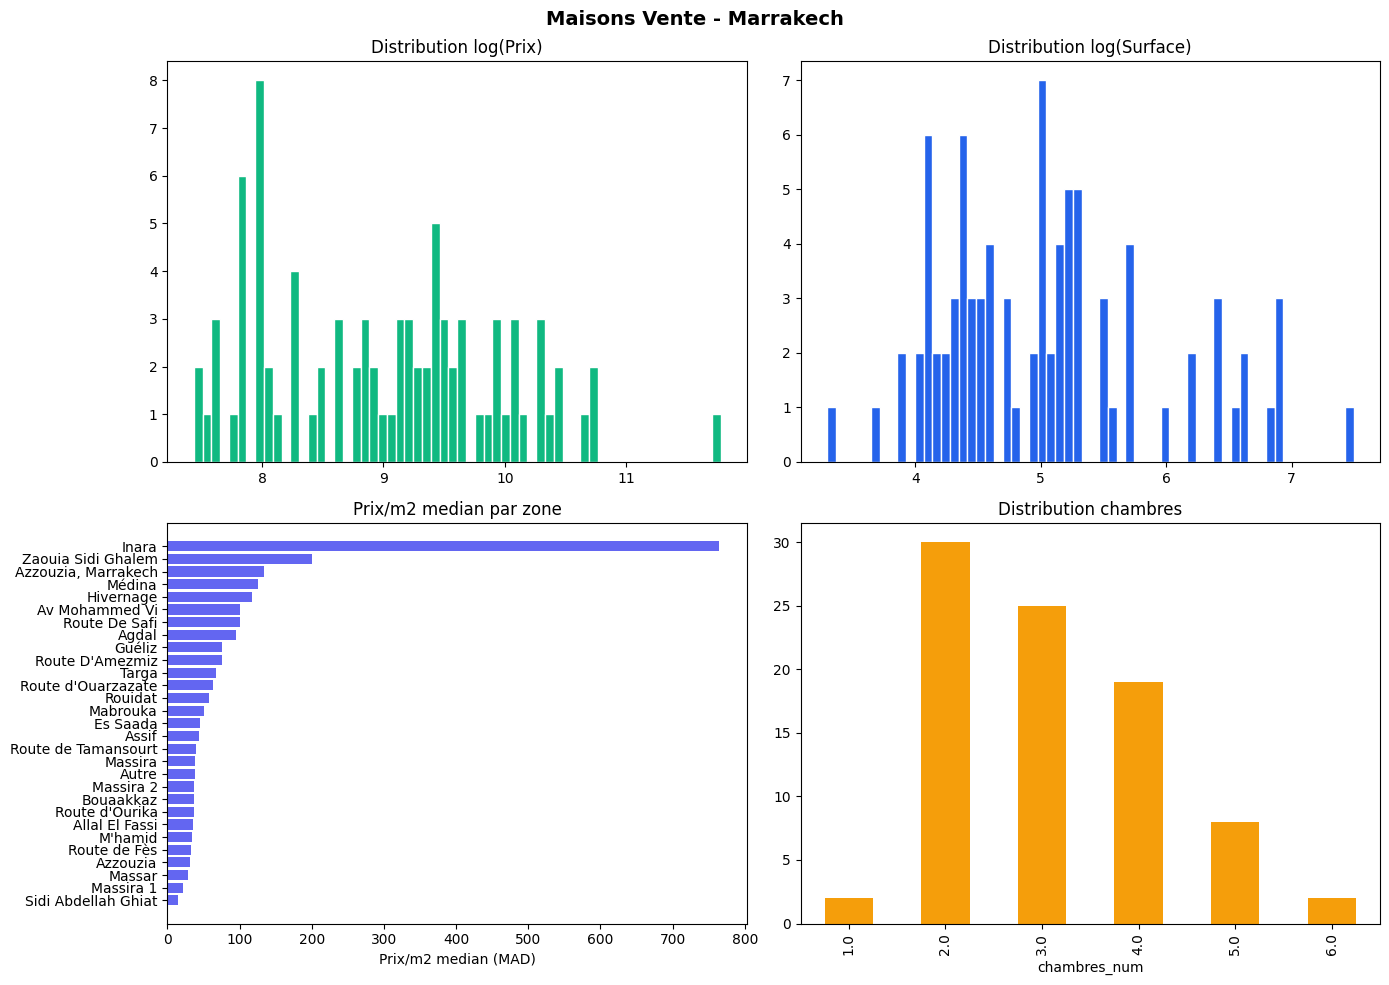

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Maisons Vente - Marrakech", fontsize=14, fontweight="bold")

axes[0,0].hist(df["log_prix"], bins=60, color="#10B981", edgecolor="white")
axes[0,0].set_title("Distribution log(Prix)")

axes[0,1].hist(df["log_surface"], bins=60, color="#2563EB", edgecolor="white")
axes[0,1].set_title("Distribution log(Surface)")

med = df.groupby("zone_clean")["prix_m2"].median().sort_values()
axes[1,0].barh(med.index, med.values, color="#6366F1")
axes[1,0].set_xlabel("Prix/m2 median (MAD)")
axes[1,0].set_title("Prix/m2 median par zone")

df["chambres_num"].value_counts().sort_index().plot(kind="bar", ax=axes[1,1], color="#F59E0B")
axes[1,1].set_title("Distribution chambres")
plt.tight_layout(); plt.show()

In [4]:
print("=== Prix median par zone ===")
print(df.groupby("zone_clean")["prix_m2"]
      .agg(["median","count"]).sort_values("median", ascending=False).round(0))

print("\n=== Variance log_prix par zone ===")
print(df.groupby("zone_clean")["log_prix"]
      .agg(["mean","std","count"]).sort_values("std", ascending=False).round(3))

print("\n=== Correlation features -> log_prix ===")
num_check = ["surface_num","log_surface","chambres_num","salles_bain_num",
             "nb_pieces","score_standing","score_confort","piscine",
             "surf_x_piscine","surf_x_ch"]
avail = [c for c in num_check if c in df.columns]
print(df[avail+["log_prix"]].corr()["log_prix"].drop("log_prix")
      .sort_values(ascending=False).round(3))

=== Prix median par zone ===
                     median  count
zone_clean                        
Inara                 765.0      1
Zaouia Sidi Ghalem    200.0      1
Azzouzia, Marrakech   133.0      1
Médina                125.0      6
Hivernage             117.0      1
Av Mohammed Vi        100.0      1
Route De Safi         100.0      1
Agdal                  95.0      2
Guéliz                 76.0      4
Route D'Amezmiz        75.0      3
Targa                  67.0      5
Route d'Ouarzazate     63.0      4
Rouidat                58.0      2
Mabrouka               50.0      1
Es Saada               45.0      1
Assif                  43.0      2
Route de Tamansourt    40.0      1
Autre                  38.0      7
Massira                38.0      1
Massira 2              37.0      3
Bouaakkaz              37.0      2
Route d'Ourika         37.0     15
Allal El Fassi         36.0      2
M'hamid                33.0      9
Route de Fès           32.0      2
Azzouzia               31.

## 2. Split et Feature Engineering

In [5]:
X_train, X_test, y_train, y_test, df_train, df_test, stats = split_and_encode(
    df, test_size=0.2, random_state=42
)
print(f"Features total : {X_train.shape[1]}")
print(f"  NUMERIC : {len(stats['numeric_cols'])}")
print(f"  CATEG   : {len(stats['categorical_cols'])}")

   Train : 68 | Test : 18
Features total : 49
  NUMERIC : 45
  CATEG   : 4


## 3. Baseline

In [6]:
pipeline_baseline = build_pipeline(X_train)
pipeline_baseline = train(pipeline_baseline, X_train, y_train)
metrics_baseline  = evaluate(pipeline_baseline, X_test, y_test, df_test,
                              X_train=X_train, y_train=y_train)

 Entraînement...

═════════════════════════════════════════════
  MÉTRIQUES — MAISON LOCATION
═════════════════════════════════════════════
  MAE              :           1,174 MAD
  RMSE             :           1,479 MAD
  R²               :          0.7603
  MAPE             :           26.35 %
  CV R² (5 folds)  : 0.8245 ± 0.0900
═════════════════════════════════════════════
  Erreur <= 10%  : 22.2% des cas
  Erreur <= 15%  : 44.4% des cas
  Erreur <= 20%  : 44.4% des cas
  Erreur <= 30%  : 61.1% des cas
  Erreur <= 50%  : 88.9% des cas


## 4. Tuning Optuna

In [7]:
best_params, study = tune_hyperparams(X_train, y_train, stats, n_trials=150)

 Optuna 150 trials sur X_train (CV 5-fold)...


Best trial: 132. Best value: 0.866667: 100%|██████████| 150/150 [00:45<00:00,  3.30it/s]

 Meilleur R² CV : 0.8667
   n_estimators                  : 1728
   max_depth                     : 4
   learning_rate                 : 0.01705093267550543
   max_leaves                    : 17
   subsample                     : 0.8716663655826326
   colsample_bytree              : 0.9894170701486306
   colsample_bylevel             : 0.9501785826774412
   min_child_weight              : 6
   reg_alpha                     : 1.4207161605259586
   reg_lambda                    : 0.010837036344704879
   gamma                         : 0.001859222532582244


In [8]:
pipeline_final = build_pipeline(stats, best_params)
pipeline_final = train(pipeline_final, X_train, y_train)
metrics_final  = evaluate(pipeline_final, X_test, y_test, df_test,
                           X_train=X_train, y_train=y_train)

r2_base = metrics_baseline["R²"]
r2_fin  = metrics_final["R²"]
mape_b  = metrics_baseline["MAPE (%)"]
mape_f  = metrics_final["MAPE (%)"]
print(f"\n=== Gain vs baseline ===")
print(f"  R2   : {r2_base:.4f} -> {r2_fin:.4f}  ({r2_fin - r2_base:+.4f})")
print(f"  MAPE : {mape_b:.2f}% -> {mape_f:.2f}%")

 Entraînement...

═════════════════════════════════════════════
  MÉTRIQUES — MAISON LOCATION
═════════════════════════════════════════════
  MAE              :           1,088 MAD
  RMSE             :           1,575 MAD
  R²               :          0.8381
  MAPE             :           21.83 %
  CV R² (5 folds)  : 0.8630 ± 0.0569
═════════════════════════════════════════════
  Erreur <= 10%  : 27.8% des cas
  Erreur <= 15%  : 44.4% des cas
  Erreur <= 20%  : 55.6% des cas
  Erreur <= 30%  : 66.7% des cas
  Erreur <= 50%  : 94.4% des cas

=== Gain vs baseline ===
  R2   : 0.7603 -> 0.8381  (+0.0779)
  MAPE : 26.35% -> 21.83%


## 5. Analyse erreurs

In [9]:
y_pred_log = pipeline_final.predict(X_test)
prix_pred  = np.exp(y_pred_log)
prix_reel  = df_test["prix_num"].values
erreur_pct = np.abs(prix_pred - prix_reel) / prix_reel * 100

df_err = X_test.copy()
df_err["erreur_pct"]  = erreur_pct
df_err["prix_reel"]   = prix_reel
df_err["prix_predit"] = prix_pred
df_err["surface"]     = df_test["surface_num"].values

print("=== MAPE par zone ===")
print(df_err.groupby("zone_clean")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== MAPE par segment_prix ===")
print(df_err.groupby("segment_prix")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== MAPE par cat_surface ===")
print(df_err.groupby("cat_surface")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== Top 10 pires predictions ===")
print(df_err.nlargest(10,"erreur_pct")[
    ["surface","zone_clean","segment_prix","prix_reel","prix_predit","erreur_pct"]
].to_string())

=== MAPE par zone ===
                    mean  count
zone_clean                     
Allal El Fassi      55.6      1
Médina              36.7      2
Bouaakkaz           33.2      1
Guéliz              30.8      3
M'hamid             24.3      2
Massira 1           16.4      1
Mabrouka            15.5      1
Autre               12.2      2
Massar              11.2      1
Targa                9.9      1
Route d'Ourika       4.7      1
Rouidat              4.2      1
Route d'Ouarzazate   3.4      1

=== MAPE par segment_prix ===
              mean  count
segment_prix             
eco           21.8     11
mid           21.8      7

=== MAPE par cat_surface ===
             mean  count
cat_surface             
small        30.5      5
medium       21.7      4
tiny         20.7      7
estate        4.7      1
large         4.2      1

=== Top 10 pires predictions ===
    surface      zone_clean segment_prix  prix_reel   prix_predit  erreur_pct
56    180.0  Allal El Fassi          mid     5

## 6. Graphiques

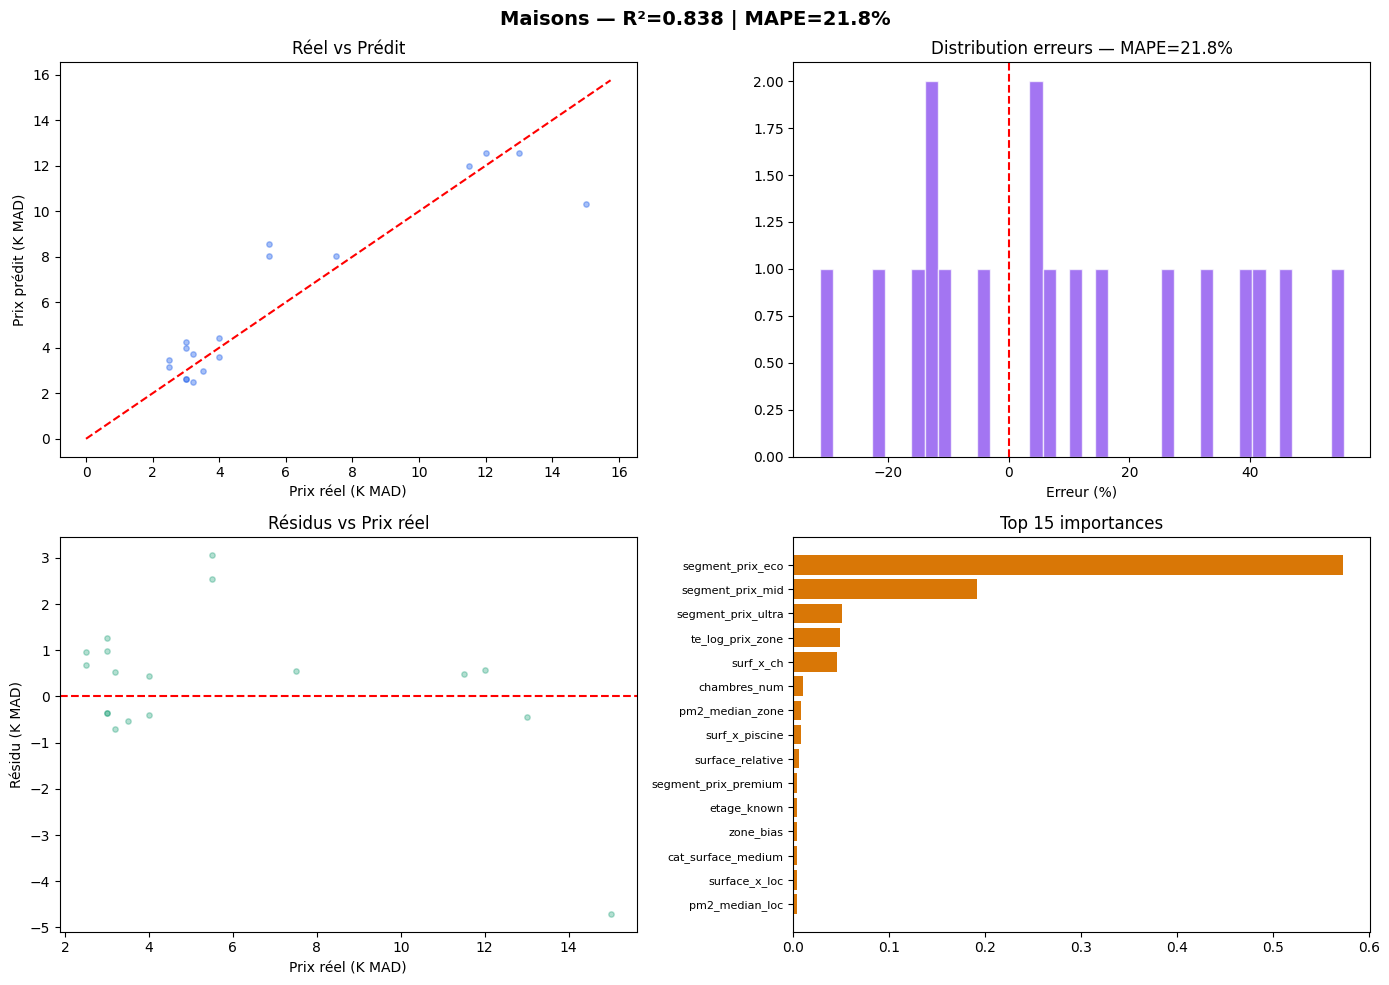

In [10]:
plot_results(pipeline_final, X_test, df_test, metrics_final)

## 7. Sauvegarde

In [11]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)

joblib.dump({"pipeline": pipeline_final, "stats": stats}, MODEL_PATH)
print(f"Modele sauvegarde -> {MODEL_PATH}")

r2_val   = round(float(metrics_final["R²"]), 4)
mape_val = round(float(metrics_final["MAPE (%)"]), 2)
mae_val  = round(float(metrics_final["MAE (MAD)"]), 0)
rmse_val = round(float(metrics_final["RMSE (MAD)"]), 0)
r2_base  = round(float(metrics_baseline["R²"]), 4)
mb_mape  = round(float(metrics_baseline["MAPE (%)"]), 2)

metadata = {
    "date"            : datetime.now().strftime("%Y-%m-%d"),
    "version"         : "v1_optuna",
    "modele"          : "XGBRegressor",
    "type_bien"       : "maison_vente",
    "target"          : "log(prix_total)",
    "n_lignes_train"  : len(X_train),
    "n_lignes_test"   : len(X_test),
    "n_features"      : X_train.shape[1],
    "n_zones"         : int(df["zone_clean"].nunique()),
    "metriques_baseline": {"R2": r2_base, "MAPE": mb_mape},
    "metriques_test"  : {"R2": r2_val, "MAE": mae_val, "RMSE": rmse_val, "MAPE": mape_val},
    "cv_r2_optuna"    : round(study.best_value, 4),
    "hyperparametres" : study.best_params,
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

df.to_csv(CLEAN_PATH, index=False)

print(f"\n" + "="*50)
print("  RESUME FINAL - MAISON LOCATION")
print("="*50)
print(f"  Donnees  : {len(df):,} maisons | {df['zone_clean'].nunique()} zones")
print(f"  R2 final : {r2_val}")
print(f"  MAE      : {mae_val:,.0f} MAD")
print(f"  MAPE     : {mape_val} %")
print(f"  CV R2    : {study.best_value:.4f}")
print("="*50)

Modele sauvegarde -> ../../model_training/models/xgb_maison_location.pkl

  RESUME FINAL - MAISON LOCATION
  Donnees  : 86 maisons | 29 zones
  R2 final : 0.8381
  MAE      : 1,088 MAD
  MAPE     : 21.83 %
  CV R2    : 0.8667


## 8. Prediction unitaire

In [12]:
saved           = joblib.load(MODEL_PATH)
pipeline_loaded = saved["pipeline"]
stats_loaded    = saved["stats"]

maison_exemple = {
    "surface_num"      : 150,
    "zone_clean"       : "M'hamid",
    "localisation_fine": "mhamid",
    "chambres_num"     : 4,
    "salles_bain_num"  : 2,
    "piscine"          : 0,
    "parking"          : 1,
    "terrasse"         : 1,
    "jardin"           : 1,
    "climatisation"    : 0,
    "titre"            : "Belle maison moderne M'hamid jardin parking",
}

result   = predict_price(pipeline_loaded, maison_exemple, stats_loaded)
prix_min = result["prix_point"] * 0.75
prix_max = result["prix_point"] * 1.25
print(f"  Fourchette : {prix_min:,.0f} - {prix_max:,.0f} MAD")


 Maison — 150 m² | M'hamid
   Prix estimé : 10,000 MAD
   Prix/m²     : 100 MAD/m²
  Fourchette : 7,709 - 12,849 MAD
